In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score,confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import joblib
import sklearn


In [4]:

df = pd.read_csv('cleaned_heart_data.csv')

X = df.drop('target', axis=1)
y = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Define feature types
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 4. Set up Scikit-Learn Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Split and Process Data for ML
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


--- Model Performance Evaluation ---

--- Logistic Regression ---
Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.79      0.84        33
     Disease       0.78      0.89      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

-------------------------

--- Decision Tree ---
Accuracy: 0.82

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.82      0.83        33
     Disease       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

-------------------

--- Random Forest ---
Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

  No Disease    

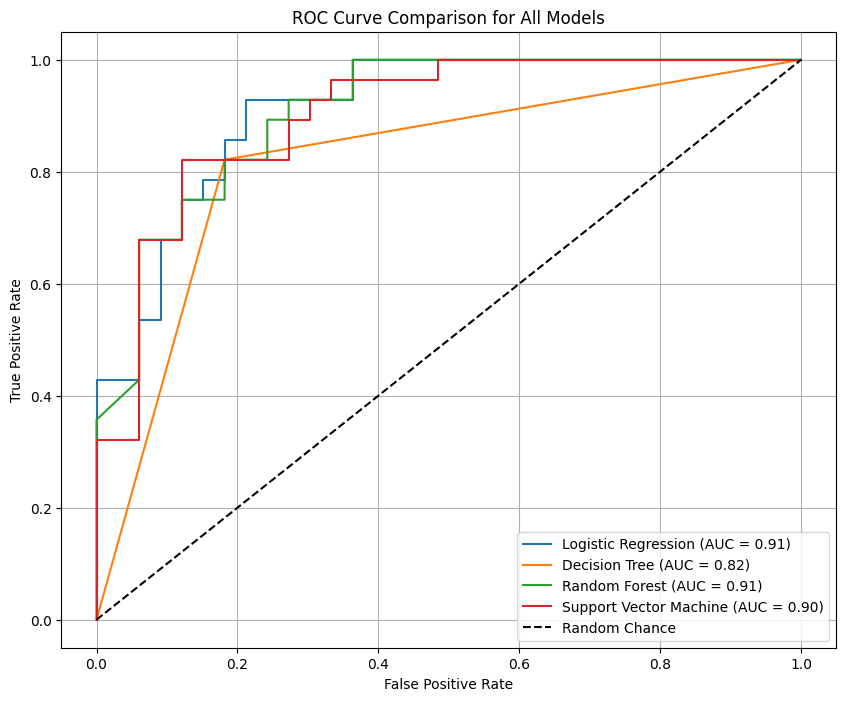

In [5]:
final_categorical = ['cp', 'thal','chol','oldpeak','thalach','exang','slope']
X_final_subset = X[final_categorical]

X_train_final, X_test_final, y_train, y_test = train_test_split(
    X_final_subset, y, test_size=0.2, random_state=42, stratify=y
)


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_final = ColumnTransformer(
    transformers=[('cat', categorical_transformer, final_categorical)])


X_train_processed_final = preprocessor_final.fit_transform(X_train_final)
X_test_processed_final = preprocessor_final.transform(X_test_final)


models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

print("--- Model Performance Evaluation ---")
for name, model in models.items():
    # Fit the model on the training data
    model.fit(X_train_processed_final, y_train)
    
    
    y_pred = model.predict(X_test_processed_final)
    
   
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
    print("-"*(len(name) + 6))


plt.figure(figsize=(10, 8))
for name, model in models.items():
    
    y_pred_proba = model.predict_proba(X_test_processed_final)[:, 1]
    
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance') 
plt.title('ROC Curve Comparison for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
